In [1]:
#import statments
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm


In [2]:
#Black - Scholes prices

S0 = 100
K = 100
T = 1
r = 0.03
sd = 0.20

d1 = (np.log(S0/K) + (r + 0.5 * sd**2) * T) / (sd * np.sqrt(T))
d2 = round(d1 - sd*np.sqrt(T),3)

V_BS = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
print("Black-Scholes price:", V_BS)

Black-Scholes price: 9.413403383853016


In [3]:
def monte_carlo(M):
    Z = np.random.normal(0,1,M)

    ST = S0 * np.exp((r - 0.5 * sd**2) * T + sd * np.sqrt(T) * Z)

    payoff = np.maximum(ST-K,0)
    
    price_est = np.exp(-r * T)*np.mean(payoff)

    sample_sd = np.std(payoff, ddof=1)
    sample_sd_error = np.exp(-r * T)*sample_sd/np.sqrt(M)
    confid_U = price_est + 1.96*sample_sd_error
    confid_L = price_est - 1.96*sample_sd_error
    confid = [float(confid_U), float(confid_L)]
    return price_est, confid



In [61]:
#convergence study
M_list = [10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5,5*10**5]
R = 100
RMSE_list = []
Vm_one = []

all_CI_l= []
all_CI_u = []
all_Vm = []

coverage_list = []

for M in M_list:

    Vm_list = np.array([])
    CI_l_list = np.array([])
    CI_u_list = np.array([])

    for x in range(R):

        Vm, con = monte_carlo(M)
        Vm_list= np.append(Vm_list, Vm)

        CI_u_list = np.append(CI_u_list, con[0])
        CI_l_list = np.append(CI_l_list, con[1])
        

    Vm_one.append(Vm_list[0])

    RMSE = np.sqrt(np.mean((Vm_list-V_BS)**2))
    RMSE_list.append(float(RMSE))


    all_Vm.append(Vm_list)
    all_CI_l.append(CI_l_list)
    all_CI_u.append(CI_u_list)

    #if interval set True
    covered = (CI_l_list <= V_BS) & (V_BS <= CI_u_list)
    coverage = np.mean(covered) #percentage for M. over all R

    coverage_list.append(coverage)

    


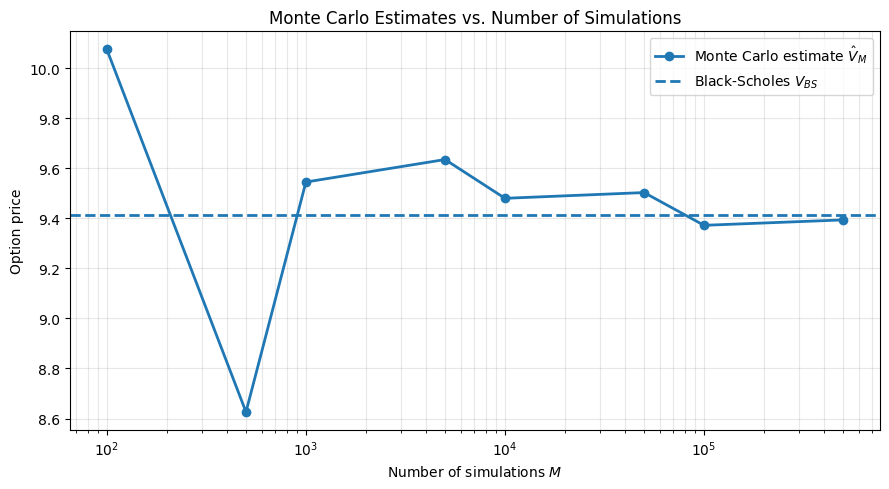

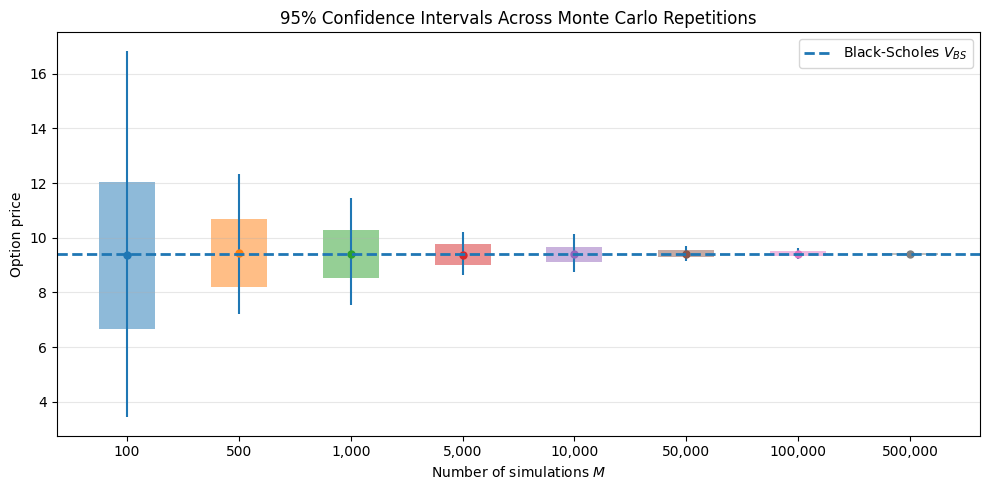

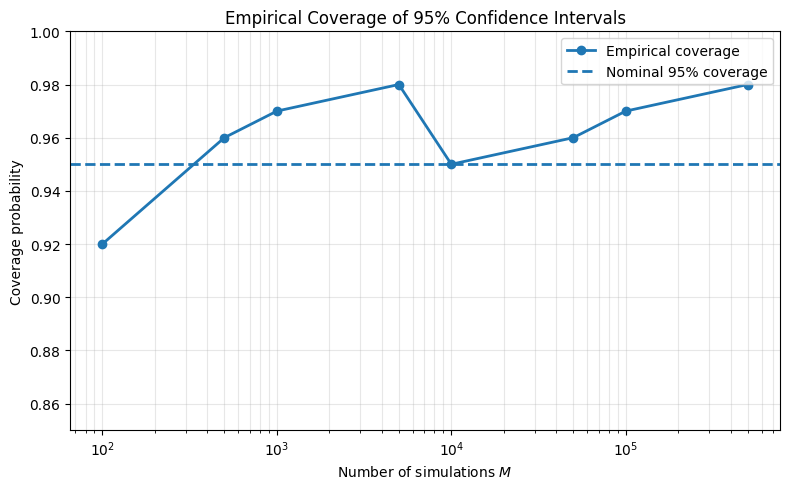

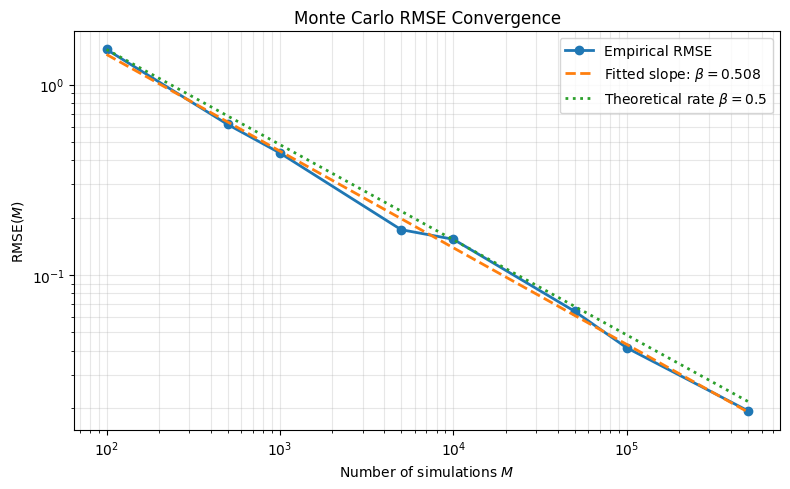

Estimated beta: 0.5078843990499088
Theoretical beta: 0.5


In [63]:
#plots
plt.figure(figsize=(9, 5))

# Representative Monte Carlo estimates
plt.plot(
    M_list,
    Vm_one,
    marker="o",
    linewidth=2,
    markersize=6,
    label=r"Monte Carlo estimate $\hat{V}_M$"
)


plt.axhline(
    y=V_BS,
    linestyle="--",
    linewidth=2,
    label=r"Black-Scholes $V_{BS}$"
)

plt.xscale("log")

plt.xlabel("Number of simulations $M$")
plt.ylabel("Option price")
plt.title("Monte Carlo Estimates vs. Number of Simulations")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


#plots for coverage and confidence interval
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(M_list))

for i, M in enumerate(M_list):

    CI_l = np.array(all_CI_l[i])
    CI_u = np.array(all_CI_u[i])
    Vm = np.array(all_Vm[i])

    # Mean confidence interval
    mean_lower = np.mean(CI_l)
    mean_upper = np.mean(CI_u)

    # Mean Monte Carlo estimate
    mean_Vm = np.mean(Vm)

    # Full range across repetitions
    min_lower = np.min(CI_l)
    max_upper = np.max(CI_u)

    # Whisker
    ax.vlines(
        i,
        min_lower,
        max_upper,
        linewidth=1.5
    )

    # Candle body = average confidence interval
    ax.bar(
        i,
        mean_upper - mean_lower,
        bottom=mean_lower,
        width=0.5,
        alpha=0.5
    )

    # Mean estimate
    ax.plot(
        i,
        mean_Vm,
        "o",
        markersize=5
    )

# Exact Black-Scholes price
ax.axhline(
    V_BS,
    linestyle="--",
    linewidth=2,
    label=r"Black-Scholes $V_{BS}$"
)

ax.set_xticks(positions)
ax.set_xticklabels([f"{M:,}" for M in M_list])

ax.set_xlabel("Number of simulations $M$")
ax.set_ylabel("Option price")
ax.set_title("95% Confidence Intervals Across Monte Carlo Repetitions")

ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    M_list,
    coverage_list,
    marker='o',
    linewidth=2,
    markersize=6,
    label="Empirical coverage"
)

plt.axhline(0.95, linestyle='--', linewidth=2, label="Nominal 95% coverage")

plt.xscale("log")
plt.ylim(0.85, 1.0)

plt.xlabel("Number of simulations $M$")
plt.ylabel("Coverage probability")
plt.title("Empirical Coverage of 95% Confidence Intervals")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#plot for rmse against M

M_array = np.array(M_list)
RMSE_array = np.array(RMSE_list)


log_M = np.log(M_array)
log_RMSE = np.log(RMSE_array)


slope, a = np.polyfit(log_M, log_RMSE, 1)


beta_est = -slope


RMSE_fit = np.exp(a) * M_array**(-beta_est)

theoretical_line = RMSE_array[0] * (M_array / M_array[0])**(-0.5)

# Plot
plt.figure(figsize=(8, 5))

plt.loglog(
    M_array,
    RMSE_array,
    marker="o",
    linewidth=2,
    markersize=6,
    label="Empirical RMSE"
)

plt.loglog(
    M_array,
    RMSE_fit,
    linestyle="--",
    linewidth=2,
    label=fr"Fitted slope: $\beta={beta_est:.3f}$"
)

plt.loglog(
    M_array,
    theoretical_line,
    linestyle=":",
    linewidth=2,
    label=r"Theoretical rate $\beta=0.5$"
)

plt.xlabel("Number of simulations $M$")
plt.ylabel("RMSE$(M)$")
plt.title("Monte Carlo RMSE Convergence")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

print("Estimated beta:", beta_est)
print("Theoretical beta:", 0.5)



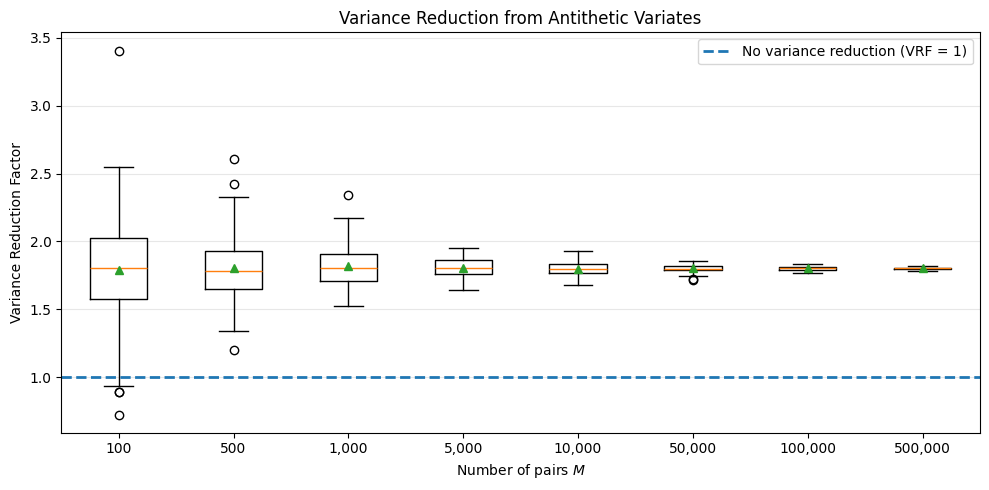

In [52]:
#antitetich variates
def antithetic_variates(M):
    Z = np.random.normal(0,1,M)
    Z2M = np.random.normal(0,1,2*M)

    ST_p = S0 * np.exp((r - 0.5 * sd**2) * T + sd * np.sqrt(T) * Z)
    ST_m = S0 * np.exp((r - 0.5 * sd**2) * T - sd * np.sqrt(T) * Z)
    ST_2M = S0 * np.exp((r - 0.5 * sd**2) * T + sd * np.sqrt(T) * Z2M)

    payoff = np.maximum(ST_2M - K, 0)

    sample_sd = np.std(payoff, ddof=1)
    sample_sd_error = np.exp(-r * T)*sample_sd/np.sqrt(2 * M)


    payoff_anti = np.maximum(ST_p - K, 0) + np.maximum(ST_m - K,0)
    payoff_anti = 0.5*payoff_anti
    sample_anti_sd = np.std(payoff_anti, ddof=1)
    sample_anti_sd_error = np.exp(-r * T)*sample_anti_sd/np.sqrt(M)

    
    Vm_anti_est = np.exp(-r * T)*np.mean(payoff_anti)

    return sample_sd_error, sample_anti_sd_error

VRF_all_list = []
for M in M_list:
    VRF_list = []
    for x in range(R):

        sample_sd_error, sample_anti_sd_error = antithetic_variates(M)
        var_standard = sample_sd_error**2
        var_antithetic = sample_anti_sd_error**2
        VRF = float(var_standard/var_antithetic)
        VRF_list.append(VRF)
    VRF_all_list.append(VRF_list)

plt.figure(figsize=(10, 5))

plt.boxplot(
    VRF_all_list,
    tick_labels=[f"{M:,}" for M in M_list],
    showmeans=True
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="No variance reduction (VRF = 1)"
)

plt.xlabel("Number of pairs $M$")
plt.ylabel("Variance Reduction Factor")
plt.title("Variance Reduction from Antithetic Variates")

plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()